In [2]:
import pandas as pd
import matplotlib.pyplot as plt

deals_df = pd.read_csv("clear_deals.csv")
projects_df = pd.read_csv("clear_projects.csv")


этаж_лота
1     0.290938
2     0.396218
3     0.354135
4     0.419798
5     0.336970
6     0.383589
7     0.319561
8     0.318744
9     0.278265
10    0.235351
11    0.205556
12    0.182642
13    0.165789
14    0.153699
15    0.160000
16    0.142445
17    0.146970
18    0.086455
19    0.087866
20    0.057018
21    0.043210
22    0.090090
24    0.030303
Name: суммарное_количество_сделок, dtype: float64


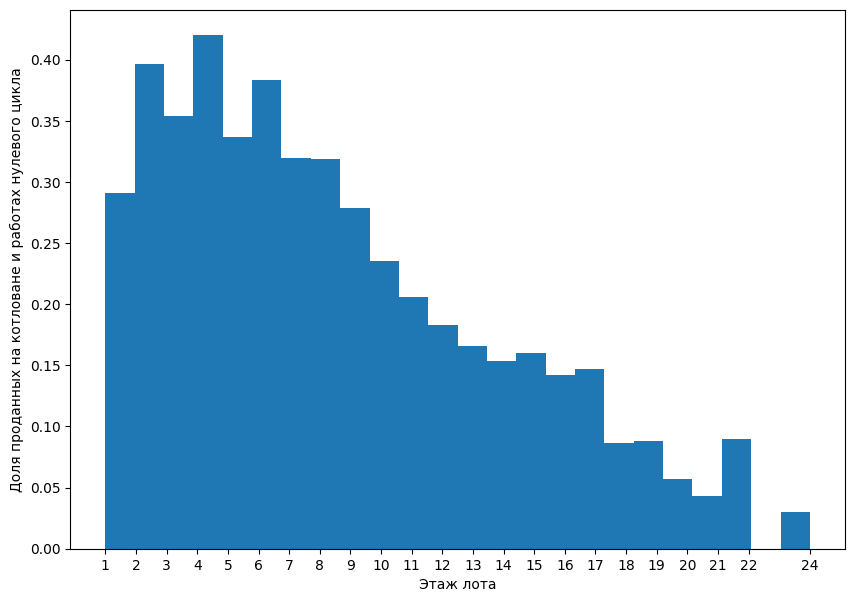

In [23]:
share = (deals_df[(deals_df["тип_лота"] == "квартира") & (deals_df["этаж_лота"] <= 24) & \
                (deals_df["текущая_стадия_строительства"].isin(["Строительство не начато", "Работы нулевого цикла"]))].groupby("этаж_лота")["суммарное_количество_сделок"].sum() \
                / deals_df[(deals_df["тип_лота"] == "квартира") & ((deals_df["этаж_лота"] <= 24))].groupby("этаж_лота")["суммарное_количество_сделок"].sum()).dropna()

print(share)

fig, ax = plt.subplots()
fig.set_size_inches(10, 7)
ax.hist(x=list(range(1, 23)) + [24], weights=share, bins=24)
ax.set_xticks(list(range(1, 23)) + [24])
ax.set_xlabel("Этаж лота")
ax.set_ylabel("Доля проданных на котловане и работах нулевого цикла")
plt.show()

In [18]:
pd.Categorical(deals_df["текущая_стадия_строительства"]).categories

Index(['Введен в эксплуатацию', 'Монтажные и отделочные работы',
       'Начало монтажных работ', 'Получение РВЭ, благоустройство территории',
       'Работы нулевого цикла', 'Строительство не начато'],
      dtype='object')

этаж_лота
1     0.009539
2     0.006227
3     0.032871
4     0.020165
5     0.047196
6     0.018012
7     0.037918
8     0.014272
9     0.020909
10    0.023956
11    0.017014
12    0.021509
13    0.027193
14    0.035800
15    0.014074
16    0.023099
17    0.006061
18    0.008646
19    0.004184
20    0.004386
21    0.006173
Name: суммарное_количество_сделок, dtype: float64
Коэффициент наклона: -0.0008
Свободный член: 0.0276
R²: 0.161


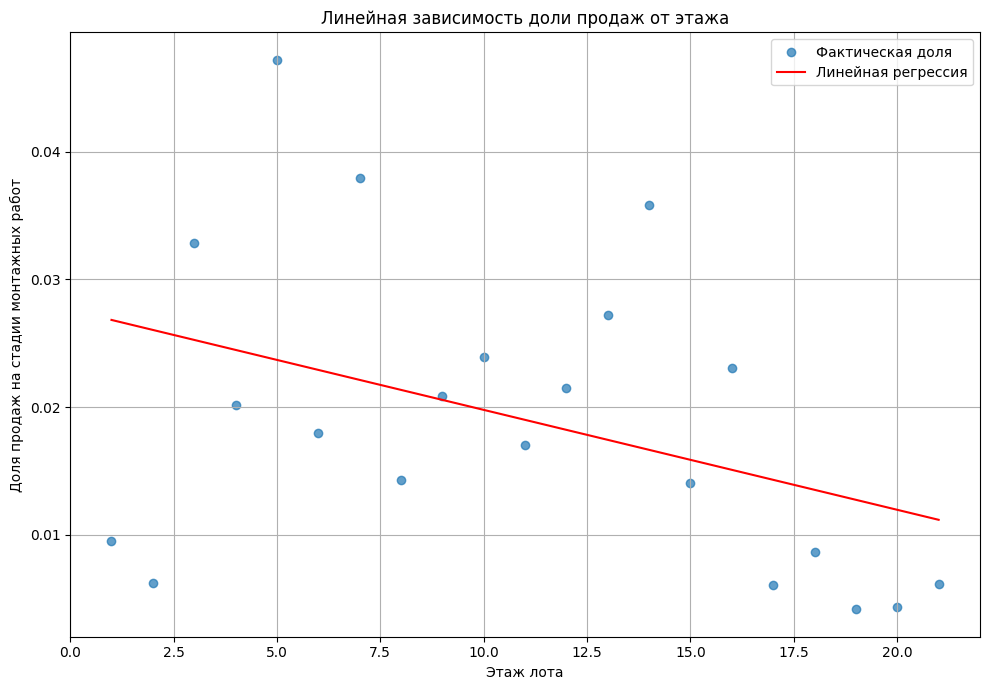

In [31]:
from sklearn.linear_model import LinearRegression

share = (deals_df[(deals_df["тип_лота"] == "квартира") & (deals_df["этаж_лота"] <= 24) & \
                (deals_df["текущая_стадия_строительства"].isin(["Введен в эксплуатацию"]))].groupby("этаж_лота")["суммарное_количество_сделок"].sum() \
                / deals_df[(deals_df["тип_лота"] == "квартира") & ((deals_df["этаж_лота"] <= 24))].groupby("этаж_лота")["суммарное_количество_сделок"].sum()).dropna()

print(share)

X = share.index.values.reshape(-1, 1)   # этажи
y = share.values                        # доли

# модель
model = LinearRegression()
model.fit(X, y)

# предсказания
y_pred = model.predict(X)

# коэффициенты
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print(f"Коэффициент наклона: {slope:.4f}")
print(f"Свободный член: {intercept:.4f}")
print(f"R²: {r2:.3f}")

# визуализация
plt.figure(figsize=(10, 7))

# точки (фактические доли)
plt.scatter(X, y, label="Фактическая доля", alpha=0.7)

# линия регрессии
plt.plot(X, y_pred, color="red", label="Линейная регрессия")

plt.xlabel("Этаж лота")
plt.ylabel("Доля продаж на стадии монтажных работ")
plt.title("Линейная зависимость доли продаж от этажа")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
projects_df

,id_корпуса,проект,класс_проекта,девелопер,конструкция_дома,этажей_от,этажей_до,адрес,плановая_дата_рвэ,стадия_строительства,тип_договора_реализации,тип_объекта_недвижимости,этаж,кол-во_комнат,общая_проектная_площадь,количество_лотов
0,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,1,92.3,3
1,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,2,197.1,4
2,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,4,75.5,1
3,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,3,65.6,1
4,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,3.0,1,87.6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21268,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,3,155.9,2
21269,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,ст,131.3,5
21270,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,2,143.4,3
21271,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,3,71.2,1


In [35]:
# этажность каждого корпуса
building_height_df = (
    projects_df
    .groupby("id_корпуса")["этаж"]
    .nunique()
    .reset_index()
    .rename(columns={
        "этаж": "building_floors_count"
    })
)

building_height_df.head()

,id_корпуса,building_floors_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,16
1,0076fc28a53eb506b7fc91475d31dea3,10
2,0081bc4d4059f46b3b42276ba8aee782,18
3,009d5290e93e353bb27e3f01b505f5b7,16
4,013e43142be6303646e81ccd28432986,18


In [36]:
deals_with_height_df = deals_df.merge(
    building_height_df,
    on="id_корпуса",
    how="left"
)

deals_with_height_df.head()

,название_региона,город,округ,район,класс,конструкция_объекта,застройщик,название_жк,адрес_корпуса,id_корпуса,...,покупатель,ипотека,название_банка,месяц,ипц,реальная_сумма_бюджета,площадь_объекта,реальная_цена_объекта,цена_за_кв_м,building_floors_count
0,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ФЛ,Ипотека,ПАО Сбербанк России,2024-12-01,116.6560,1.133937e+07,36.1,1.133937e+07,314109.861473,16.0
1,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ФЛ,Ипотека,ПАО Сбербанк России,2024-09-01,112.6680,1.154491e+07,38.5,1.154491e+07,299867.762035,16.0
2,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ФЛ,Нет,NaN,2024-11-01,115.1362,1.558428e+07,61.0,1.558428e+07,255480.031476,16.0
3,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ФЛ,Ипотека,ПАО Совкомбанк,2024-12-01,116.6560,1.481381e+07,59.4,1.481381e+07,249390.665790,16.0
4,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ФЛ,Нет,NaN,2024-09-01,112.6680,1.536217e+07,61.0,1.536217e+07,251838.900539,16.0


In [ ]:

deals_df

,название_региона,город,округ,район,класс,конструкция_объекта,застройщик,название_жк,адрес_корпуса,id_корпуса,...,продавец,покупатель,ипотека,название_банка,месяц,ипц,реальная_сумма_бюджета,площадь_объекта,реальная_цена_объекта,цена_за_кв_м
0,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ФЛ,ФЛ,Ипотека,ПАО Сбербанк России,2024-12-01,116.6560,1.133937e+07,36.1,1.133937e+07,314109.861473
1,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ЮЛ,ФЛ,Ипотека,ПАО Сбербанк России,2024-09-01,112.6680,1.154491e+07,38.5,1.154491e+07,299867.762035
2,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ЮЛ,ФЛ,Нет,NaN,2024-11-01,115.1362,1.558428e+07,61.0,1.558428e+07,255480.031476
3,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ЮЛ,ФЛ,Ипотека,ПАО Совкомбанк,2024-12-01,116.6560,1.481381e+07,59.4,1.481381e+07,249390.665790
4,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,ЮЛ,ФЛ,Нет,NaN,2024-09-01,112.6680,1.536217e+07,61.0,1.536217e+07,251838.900539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50950,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Николо-Хованское дер., д. 8.1",feb775e64315735a2d87a5a88937c947,...,ЮЛ,ФЛ,Ипотека,ПАО Сбербанк России,2024-05-01,109.9410,1.708506e+07,51.2,1.708506e+07,333692.616949
50951,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Николо-Хованское дер., д. 8.1",feb775e64315735a2d87a5a88937c947,...,ЮЛ,ФЛ,Ипотека,ПАО Банк ВТБ,2024-06-01,110.6446,1.697642e+07,51.2,1.697642e+07,331570.632457
50952,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Николо-Хованское дер., д. 8.1",feb775e64315735a2d87a5a88937c947,...,ЮЛ,ФЛ,Ипотека,ПАО Банк ВТБ,2024-04-01,109.1334,1.630846e+07,59.8,1.630846e+07,272716.693515
50953,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Николо-Хованское дер., д. 8.1",feb775e64315735a2d87a5a88937c947,...,ЮЛ,ФЛ,Ипотека,ПАО Банк ВТБ,2024-06-01,110.6446,1.880253e+07,69.9,1.880253e+07,268991.889347


In [47]:
# этажность каждого корпуса
building_height_df = (
    projects_df
    .groupby("id_корпуса")["этаж"]
    .nunique()
    .reset_index()
    .rename(columns={
        "этаж": "building_floors_count"
    })
)

building_height_df.head()

share_by_height_df = (
    deals_with_height_df[
        (deals_with_height_df["тип_лота"] == "квартира") &
        (deals_with_height_df["этаж_лота"] <= 24)
    ]
    .groupby(["building_floors_count"])
    .agg(
        # числитель: сделки после ввода
        commissioned_sales=(
            "суммарное_количество_сделок",
            lambda x: x[
                deals_with_height_df.loc[x.index, "текущая_стадия_строительства"]
                == "Введен в эксплуатацию"
            ].sum()
        ),
        # знаменатель: все сделки
        total_sales=("суммарное_количество_сделок", "sum"),
        # количество записей
        records_count=("суммарное_количество_сделок", "count")
    )
    .reset_index()
)

# считаем долю
share_by_height_df["share_commissioned"] = (
    share_by_height_df["commissioned_sales"]
    / share_by_height_df["total_sales"]
)

share_by_height_df


,building_floors_count,commissioned_sales,total_sales,records_count,share_commissioned
0,5.0,0,36,36,0.000000
1,6.0,0,9,9,0.000000
2,7.0,5,61,61,0.081967
3,8.0,0,422,416,0.000000
4,9.0,23,971,968,0.023687
5,10.0,1,2929,2895,0.000341
6,11.0,1,1602,1583,0.000624
7,12.0,13,1109,1098,0.011722
8,13.0,50,2013,1987,0.024839
9,14.0,165,3564,3442,0.046296
